# Cross-method noise floor analysis (Stream F)

Reads per-vertical noise-floor parquets produced by `analysis-noise-floors`.
Plan: `docs/plans/2026-05-03-analysis-implementation-plan_F_noise_floors.md`

**Headline figures (per-scheme summaries):**
- F5a `_per_scheme`: charge MAR vs all other schemes, per vertical (6 columns)
- F5b `_per_scheme`: bond-order MAR vs all other schemes, per vertical (3 columns)
- F6a per-element charge MAR (element x scheme-pair) -- B1 detail
- F6b ECP outlier diagnostic on TM atoms -- B1 caveat

**Reference figures (pairwise breakouts, kept for appendix):**
- F5a `_heatmap`: vertical x 15 charge scheme-pairs
- F5b `_heatmap`: vertical x 3 bond scheme-pairs

**Parquet outputs (no figure):**
- `T4_per_vertical_floor.parquet` -- T4 LaTeX table source
- `top_exemplars.parquet` -- 100 charge + 100 bond rows for §6.5 case studies
- `bond_parser_artifacts.parquet` -- bond rows with residual >= 5

**MAR definition.** For a scheme pair `(A, B)`, residual at each atom is `|q_A - q_B|`.
MAR is the median of those absolute residuals across all atoms. Robust pairwise
statistic in physical units (e for charges, BO units for bonds). Not a variance.

**Per-scheme summary**: for each (vertical, scheme), n-weighted mean of MAR across
all pairs the scheme participates in. One number per (vertical, scheme) instead of
per (vertical, scheme-pair). Compresses 15 charge columns to 6 and 3 bond columns
to 3, cleaner read of "how noisy is this method overall".


In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "axes.grid":         False,   # heatmaps: no grid overlay
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "figure.dpi":        150,
})

DATA = Path("../../data/OMol4M_lmdbs/noise")
SAVE = Path("../../docs/neurips/figures/noise")
SAVE.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(SAVE / f"{name}.{ext}", dpi=300, bbox_inches="tight")
    print(f"saved {name}")


CHARGE_SCHEMES = ["hirshfeld", "cm5", "adch", "becke", "mulliken_orca", "loewdin_orca"]
BOND_SCHEMES = ["fuzzy_bond", "mayer_orca", "loewdin_orca"]
ECP_ELEMENTS = {"Mo", "Ru", "Pt", "Pd", "Cu", "Fe", "Ni", "Co", "Mn", "Zn",
                "Ag", "Au", "W", "Re", "Os", "Ir", "Hf", "Ta", "Rh", "Cd",
                "Ca", "Ba", "Sr"}
SCHEME_COLORS = {
    "hirshfeld":     "#0072B2",
    "cm5":           "#56B4E9",
    "adch":          "#D55E00",
    "becke":         "#CC79A7",
    "mulliken_orca": "#E69F00",
    "loewdin_orca":  "#009E73",
}

nf_files = sorted(DATA.glob("*_nf.parquet"))
nf = pd.concat([pd.read_parquet(f) for f in nf_files], ignore_index=True)
VERTICALS = sorted(nf["vertical"].unique())
global_rows = nf[nf["element"].isna() & nf["element_pair"].isna()].copy()
pair_order = [f"{a}_vs_{b}" for a, b in combinations(CHARGE_SCHEMES, 2)]
print(f"verticals: {len(VERTICALS)}  ({', '.join(VERTICALS)})")


def per_scheme_summary(df_global, schemes):
    """For each (vertical, scheme), n-weighted mean MAR across all pairs the scheme participates in."""
    rows = []
    for v in df_global["vertical"].unique():
        sub = df_global[df_global["vertical"] == v]
        for s in schemes:
            mask = sub["descriptor"].str.startswith(f"{s}_vs_") | sub["descriptor"].str.endswith(f"_vs_{s}")
            sel = sub[mask]
            if len(sel):
                w = sel["n_obs"].fillna(0).astype(float)
                m = sel["mar"].astype(float)
                total = w.sum()
                rows.append({
                    "vertical": v,
                    "scheme":   s,
                    "mar_mean": float((m * w).sum() / total) if total else float("nan"),
                })
    return pd.DataFrame(rows)


def _annotate_heatmap(ax, values, threshold, fmt="{:.3f}"):
    for ri in range(values.shape[0]):
        for ci in range(values.shape[1]):
            v = values[ri, ci]
            if pd.notna(v):
                ax.text(ci, ri, fmt.format(v), ha="center", va="center",
                        fontsize=6, color="white" if v > threshold else "black")


verticals: 17  (5A_elytes, ani1xbb, ani2x, dna, droplet, electrolytes_reactivity, electrolytes_redox, electrolytes_scaled_sep, geom_orca6, low_spin_23, ml_elytes, ml_mo, ml_protein_interface, mo_hydrides, nakb, noble_gas, noble_gas_compounds)


## F5a (headline). Charge MAR per scheme -- mean vs all other schemes

saved F5a_charge_mar_per_scheme


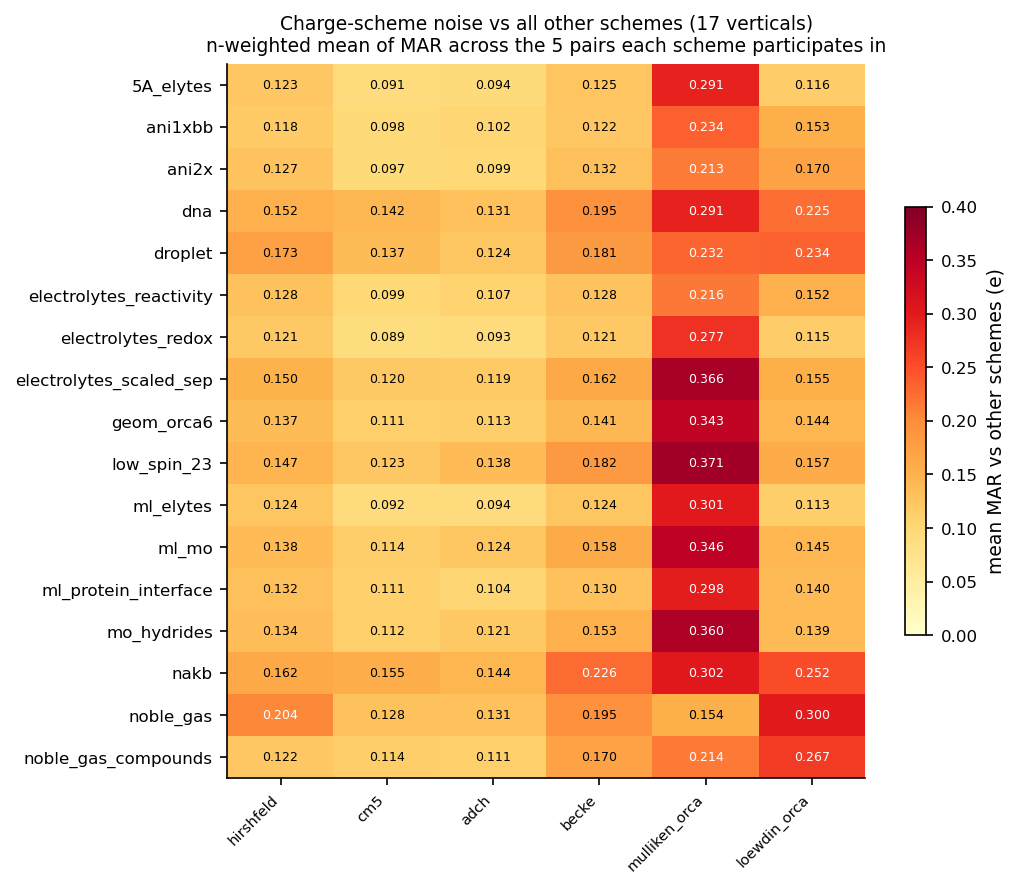


Most-noisy scheme (median across verticals):
scheme
mulliken_orca    0.291
loewdin_orca     0.153
becke            0.153
hirshfeld        0.134
adch             0.113
cm5              0.112


In [2]:
charge_global = global_rows[global_rows["analysis"] == "charge"].copy()
charge_per_scheme = per_scheme_summary(charge_global, CHARGE_SCHEMES)
piv = charge_per_scheme.pivot(index="vertical", columns="scheme", values="mar_mean")
piv = piv.reindex(columns=CHARGE_SCHEMES, index=sorted(piv.index))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.4)
ax.set_xticks(range(len(CHARGE_SCHEMES)))
ax.set_xticklabels(CHARGE_SCHEMES, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels(piv.index, fontsize=8)
ax.grid(False)
_annotate_heatmap(ax, piv.values, threshold=0.2)
plt.colorbar(im, ax=ax, label="mean MAR vs other schemes (e)", shrink=0.6)
ax.set_title(f"Charge-scheme noise vs all other schemes ({len(piv.index)} verticals)\n"
             "n-weighted mean of MAR across the 5 pairs each scheme participates in")
plt.tight_layout()
save(fig, "F5a_charge_mar_per_scheme")
plt.show()

print("\nMost-noisy scheme (median across verticals):")
print(piv.median().sort_values(ascending=False).round(3).to_string())


## F5b (headline). Bond-order MAR per scheme -- mean vs all other schemes

saved F5b_bond_mar_per_scheme


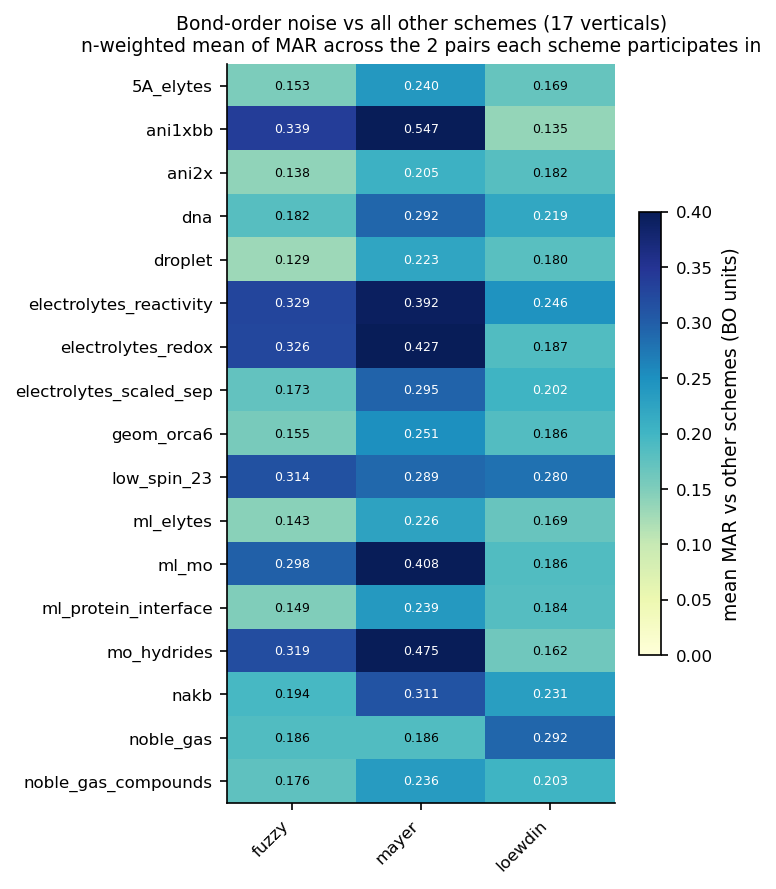


Most-noisy bond scheme (median across verticals):
scheme
mayer_orca      0.289
loewdin_orca    0.186
fuzzy_bond      0.182


In [3]:
bond_global = global_rows[global_rows["analysis"] == "bond_order"].copy()
bond_per_scheme = per_scheme_summary(bond_global, BOND_SCHEMES)
piv_b = bond_per_scheme.pivot(index="vertical", columns="scheme", values="mar_mean")
piv_b = piv_b.reindex(columns=BOND_SCHEMES, index=sorted(piv_b.index))

short_labels = [s.replace("_orca", "").replace("_bond", "") for s in BOND_SCHEMES]

fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(piv_b.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=0.4)
ax.set_xticks(range(len(BOND_SCHEMES)))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(piv_b.index)))
ax.set_yticklabels(piv_b.index, fontsize=8)
ax.grid(False)
_annotate_heatmap(ax, piv_b.values, threshold=0.2)
plt.colorbar(im, ax=ax, label="mean MAR vs other schemes (BO units)", shrink=0.6)
ax.set_title(f"Bond-order noise vs all other schemes ({len(piv_b.index)} verticals)\n"
             "n-weighted mean of MAR across the 2 pairs each scheme participates in")
plt.tight_layout()
save(fig, "F5b_bond_mar_per_scheme")
plt.show()

print("\nMost-noisy bond scheme (median across verticals):")
print(piv_b.median().sort_values(ascending=False).round(3).to_string())


## F5a (reference). Charge MAR full pairwise breakout

Kept for appendix / supplementary. 15 columns is too noisy for the headline read but
useful for diagnosing specific scheme-pair disagreements.


saved F5a_charge_mar_heatmap


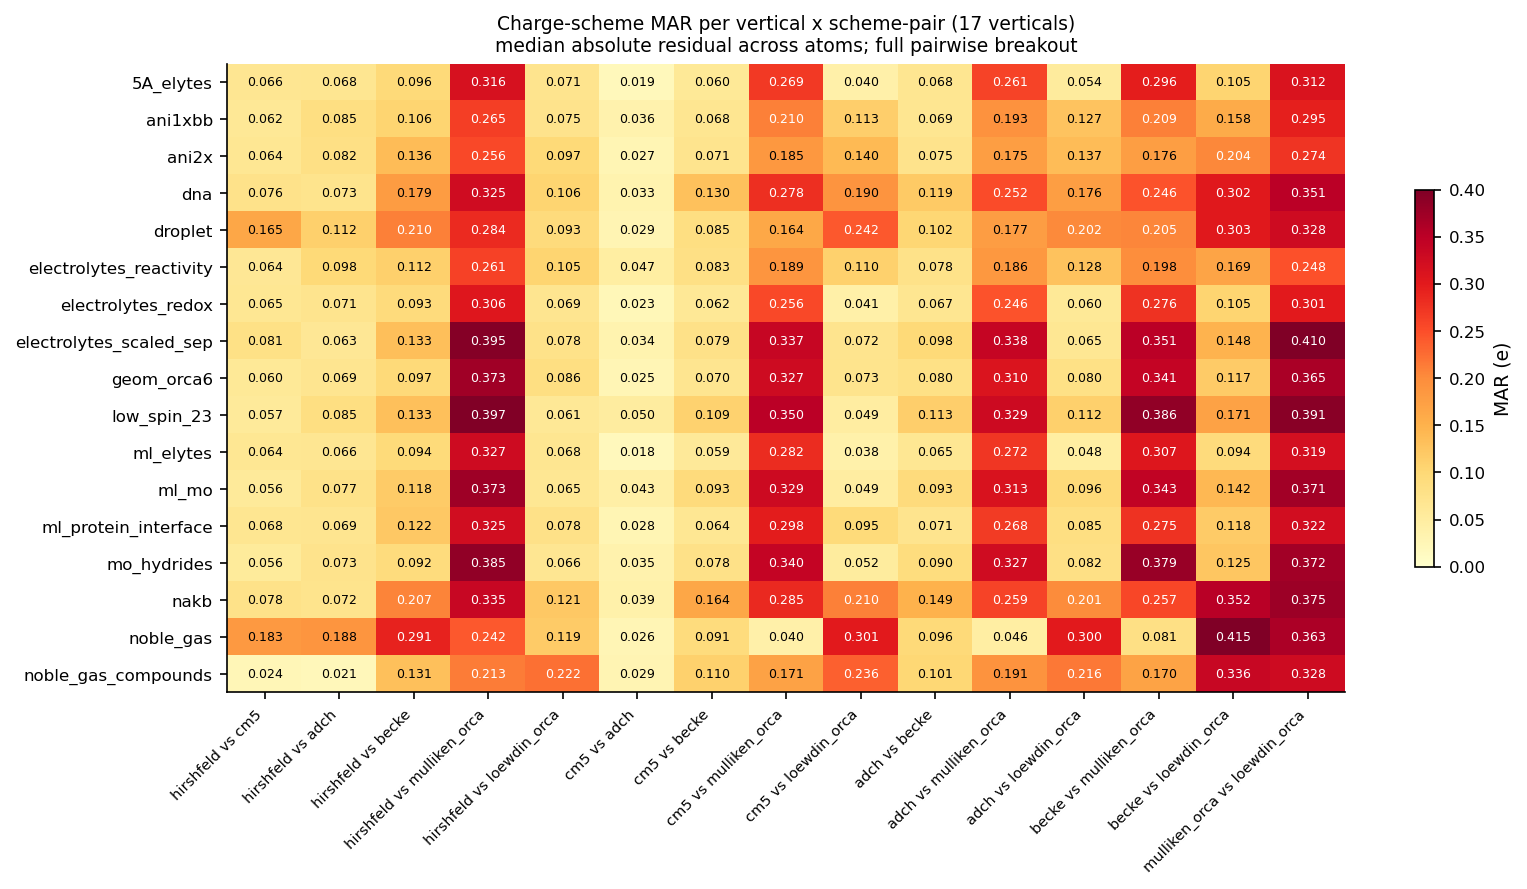

In [4]:
pivot_a = charge_global.pivot(index="vertical", columns="descriptor", values="mar")
pivot_a = pivot_a.reindex(columns=[c for c in pair_order if c in pivot_a.columns])
pivot_a = pivot_a.reindex(index=sorted(pivot_a.index))

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_a.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.4)
ax.set_xticks(range(len(pivot_a.columns)))
ax.set_xticklabels([c.replace("_vs_", " vs ") for c in pivot_a.columns],
                   rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot_a.index)))
ax.set_yticklabels(pivot_a.index, fontsize=8)
ax.grid(False)
_annotate_heatmap(ax, pivot_a.values, threshold=0.2)
plt.colorbar(im, ax=ax, label="MAR (e)", shrink=0.6)
ax.set_title(f"Charge-scheme MAR per vertical x scheme-pair ({len(pivot_a.index)} verticals)\n"
             "median absolute residual across atoms; full pairwise breakout")
plt.tight_layout()
save(fig, "F5a_charge_mar_heatmap")
plt.show()


## F5b (reference). Bond-order MAR full pairwise breakout

saved F5b_bond_mar_heatmap


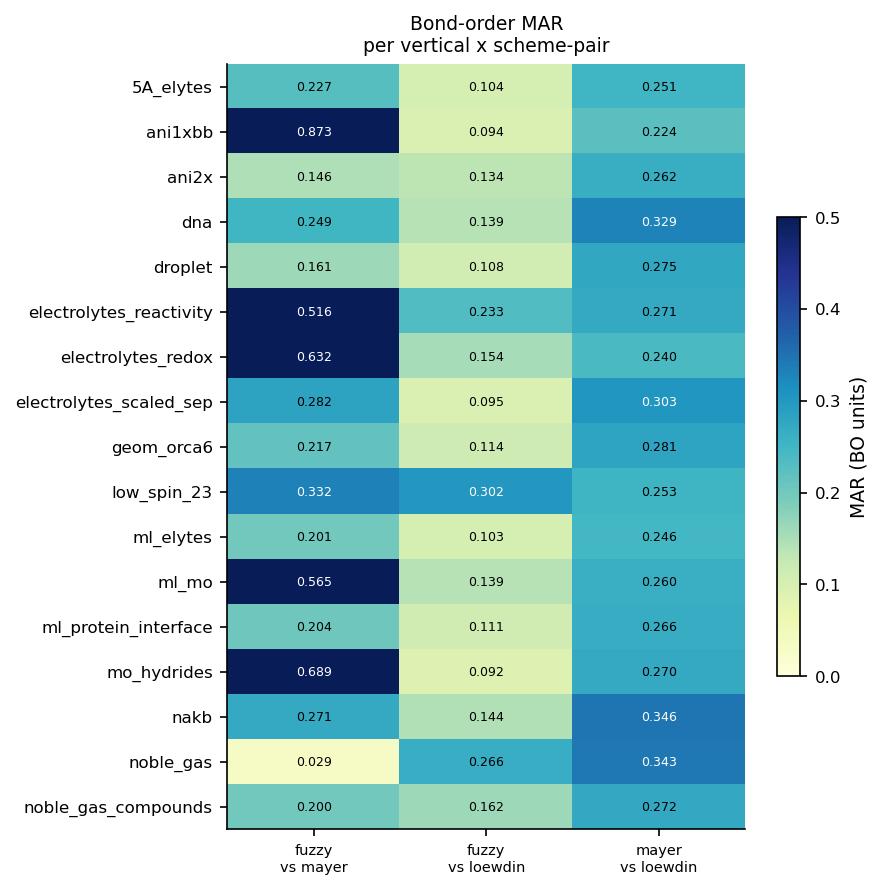

In [5]:
pivot_b = bond_global.pivot(index="vertical", columns="descriptor", values="mar")
bond_pair_order = [f"{a}_vs_{b}" for a, b in combinations(BOND_SCHEMES, 2)]
pivot_b = pivot_b.reindex(columns=[c for c in bond_pair_order if c in pivot_b.columns])
pivot_b = pivot_b.reindex(index=sorted(pivot_b.index))

short_pair = [c.replace("_vs_", "\nvs ").replace("_bond", "").replace("_orca", "")
              for c in pivot_b.columns]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(pivot_b.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=0.5)
ax.set_xticks(range(len(pivot_b.columns)))
ax.set_xticklabels(short_pair, fontsize=7)
ax.set_yticks(range(len(pivot_b.index)))
ax.set_yticklabels(pivot_b.index, fontsize=8)
ax.grid(False)
_annotate_heatmap(ax, pivot_b.values, threshold=0.3)
plt.colorbar(im, ax=ax, label="MAR (BO units)", shrink=0.6)
ax.set_title("Bond-order MAR\nper vertical x scheme-pair")
plt.tight_layout()
save(fig, "F5b_bond_mar_heatmap")
plt.show()


## F6a. Per-element charge MAR (element x scheme-pair)

saved F6a_charge_mar_per_element


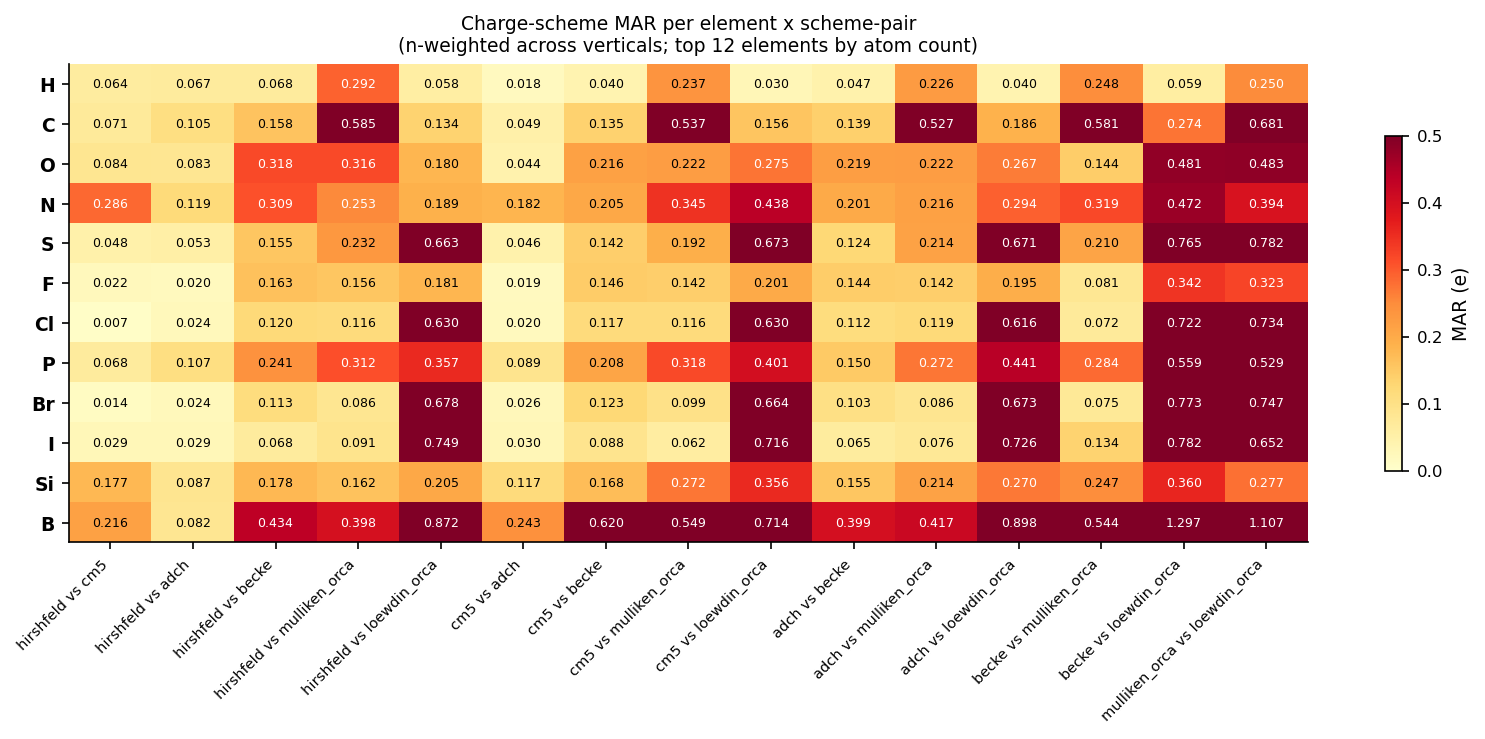

In [6]:
elem_rows = nf[(nf["analysis"] == "charge") & nf["element"].notna() & nf["element_pair"].isna()].copy()
combined_elem = (
    elem_rows.assign(mar_n=elem_rows["mar"] * elem_rows["n_obs"])
    .groupby(["element", "descriptor"])
    .agg(mar_n=("mar_n", "sum"), n=("n_obs", "sum"))
    .reset_index()
)
combined_elem["mar"] = combined_elem["mar_n"] / combined_elem["n"]

top_elems = (
    combined_elem.groupby("element")["n"].sum().sort_values(ascending=False).head(12).index.tolist()
)
pivot_c = combined_elem[combined_elem["element"].isin(top_elems)].pivot(
    index="element", columns="descriptor", values="mar"
).reindex(index=top_elems, columns=[c for c in pair_order if c in combined_elem["descriptor"].unique()])

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot_c.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5)
ax.set_xticks(range(len(pivot_c.columns)))
ax.set_xticklabels([c.replace("_vs_", " vs ") for c in pivot_c.columns],
                   rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot_c.index)))
ax.set_yticklabels(pivot_c.index, fontsize=9, fontweight="bold")
ax.grid(False)
_annotate_heatmap(ax, pivot_c.values, threshold=0.25)
plt.colorbar(im, ax=ax, label="MAR (e)", shrink=0.7)
ax.set_title("Charge-scheme MAR per element x scheme-pair\n"
             "(n-weighted across verticals; top 12 elements by atom count)")
plt.tight_layout()
save(fig, "F6a_charge_mar_per_element")
plt.show()


## F6b. ECP outlier diagnostic

ECP-element atom rows: 50,375


saved F6b_ecp_outlier_diagnostic


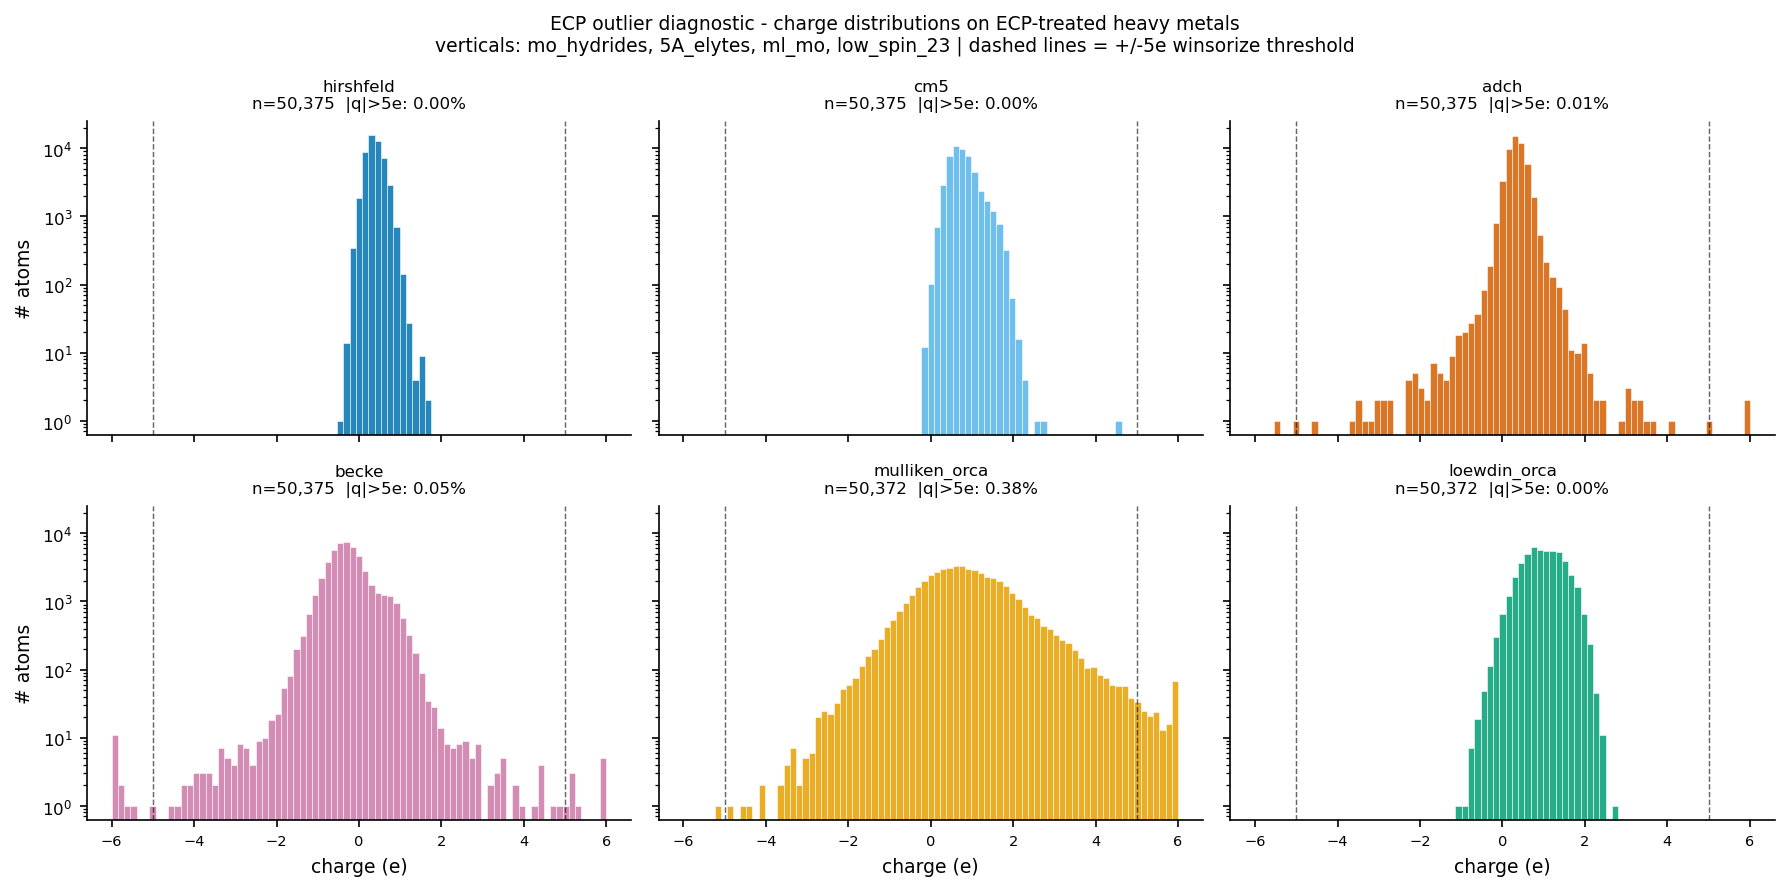

In [7]:
ecp_focus_verticals = [v for v in ["mo_hydrides", "5A_elytes", "ml_mo", "low_spin_23"] if v in VERTICALS]
ecp_charge_dfs = []
for v in ecp_focus_verticals:
    p = DATA / f"{v}_nf_charge_atoms.parquet"
    if p.exists():
        df = pd.read_parquet(p)
        ecp_charge_dfs.append(df[df["element"].isin(ECP_ELEMENTS)])
ecp_df = pd.concat(ecp_charge_dfs, ignore_index=True) if ecp_charge_dfs else pd.DataFrame()
print(f"ECP-element atom rows: {len(ecp_df):,}")

if len(ecp_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
    bins = np.linspace(-6, 6, 80)
    for ax, scheme in zip(axes.flat, CHARGE_SCHEMES):
        col = f"charge_{scheme}"
        vals = ecp_df[col].dropna().values
        clipped = vals.clip(-6, 6)
        ax.hist(clipped, bins=bins, color=SCHEME_COLORS[scheme],
                alpha=0.85, edgecolor="white", linewidth=0.3)
        ax.axvline(-5, color="k", linestyle="--", linewidth=0.7, alpha=0.6)
        ax.axvline(5,  color="k", linestyle="--", linewidth=0.7, alpha=0.6)
        outlier_frac = float(((vals < -5) | (vals > 5)).mean()) if len(vals) else 0.0
        ax.set_title(f"{scheme}\nn={int(np.isfinite(vals).sum()):,}  |q|>5e: {outlier_frac*100:.2f}%",
                     fontsize=8)
        ax.set_yscale("log")
    for ax in axes[-1, :]:
        ax.set_xlabel("charge (e)")
    for ax in axes[:, 0]:
        ax.set_ylabel("# atoms")
    fig.suptitle(
        f"ECP outlier diagnostic - charge distributions on ECP-treated heavy metals\n"
        f"verticals: {', '.join(ecp_focus_verticals)} | dashed lines = +/-5e winsorize threshold",
        fontsize=9,
    )
    plt.tight_layout()
    save(fig, "F6b_ecp_outlier_diagnostic")
    plt.show()


## T4 source + top-exemplar parquets (no figure)

In [8]:
floor_rows = []
for v in VERTICALS:
    sub = global_rows[global_rows["vertical"] == v]
    floor_rows.append({
        "vertical": v,
        "charge_floor_e": sub[sub["analysis"] == "charge"]["mar"].median(),
        "bond_floor": sub[sub["analysis"] == "bond_order"]["mar"].median(),
        "n_charge_obs": sub[sub["analysis"] == "charge"]["n_obs"].max(),
        "n_bond_obs":   sub[sub["analysis"] == "bond_order"]["n_obs"].max(),
    })
floor = pd.DataFrame(floor_rows).set_index("vertical").sort_values("charge_floor_e")
floor.to_parquet(SAVE / "T4_per_vertical_floor.parquet")
print(f"wrote {SAVE/'T4_per_vertical_floor.parquet'}")
print(floor.round(3).to_string())

ex_dfs = []
for v in VERTICALS:
    p = DATA / f"{v}_nf_exemplars.parquet"
    if p.exists():
        ex_dfs.append(pd.read_parquet(p))
ex_all = pd.concat(ex_dfs, ignore_index=True)

ex_charge       = ex_all[ex_all["descriptor"] == "charge"].copy()
ex_bond_clean   = ex_all[(ex_all["descriptor"] == "bond_order") & (ex_all["residual"] < 5)].copy()
ex_bond_corrupt = ex_all[(ex_all["descriptor"] == "bond_order") & (ex_all["residual"] >= 5)].copy()
top_exemplars = pd.concat(
    [ex_charge.nlargest(100, "residual"), ex_bond_clean.nlargest(100, "residual")],
    ignore_index=True,
)
top_exemplars.to_parquet(SAVE / "top_exemplars.parquet")
print(f"\nwrote {SAVE/'top_exemplars.parquet'} ({len(top_exemplars)} rows)")
if len(ex_bond_corrupt):
    ex_bond_corrupt.to_parquet(SAVE / "bond_parser_artifacts.parquet")
    print(f"wrote {SAVE/'bond_parser_artifacts.parquet'} ({len(ex_bond_corrupt)} rows)")


wrote ../../docs/neurips/figures/noise/T4_per_vertical_floor.parquet
                         charge_floor_e  bond_floor  n_charge_obs  n_bond_obs
vertical                                                                     
ml_elytes                         0.068       0.201       7608642    13400770
electrolytes_redox                0.071       0.240       4017583     8778537
5A_elytes                         0.071       0.227       2324023     4190341
geom_orca6                        0.086       0.217      10321888    22826559
mo_hydrides                       0.090       0.270        232942      759393
ml_protein_interface              0.095       0.204       8314895    15474467
ml_mo                             0.096       0.260       6098677    17456047
electrolytes_scaled_sep           0.098       0.282       2307396     5367052
electrolytes_reactivity           0.112       0.271        874449     1886672
ani1xbb                           0.113       0.224      10834251    2684